# TF-IDF — notebook thử nghiệm & đánh giá (import từ backend)

**Quy tắc:** code chính nằm trong `backend/app/services/summarization/tfidf_summarizer.py`; notebook chỉ **gọi lại**, phân tích và ghi nhận kết quả cho đồ án.

**Cách hoạt động (tóm tắt trích xuất theo câu):**

- Mỗi **câu** = một "tài liệu" nhỏ.
- **TF**: tần suất từ trong câu (chuẩn hóa theo độ dài câu).
- **IDF**: log làm mịn theo số câu chứa từ đó.
- Xếp hạng câu theo điểm TF-IDF → chọn top `k` → **sắp lại theo thứ tự xuất hiện** trong văn gốc.

**Ba vai trò của notebook này**

1. **Debug / hợp lý hóa:** điểm từng câu, chỉ số được chọn, so sánh `k` cố định và tỷ lệ nén (ví dụ 20% / 30% / 40% số câu).
2. **Chất lượng trên mẫu:** nhiều đoạn (tin ngắn, văn nhiễu, kiểu copy từ web/PDF).
3. **Chuẩn bị evaluation:** ô cuối (ROUGE) — cài `rouge-score` nếu cần; sau này có thể gom chung notebook *Evaluation* khi đã có TextRank / BARTpho.

**Chạy notebook:** từ gốc repo, `backend/`, hoặc `notebooks/` — ô tiếp theo thêm `backend` vào `PYTHONPATH`.

In [50]:
from __future__ import annotations

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
# Thư mục chứa package `app`: có thể là repo/backend, hoặc đang đứng trong backend/
candidates = [
    cwd / "backend",
    cwd,
    cwd.parent / "backend",
]
BACKEND_ROOT = next((c for c in candidates if (c / "app").is_dir()), None)
if BACKEND_ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy thư mục chứa package `app`. "
        "Chạy notebook từ gốc repo, từ `backend/`, hoặc từ `notebooks/`."
    )

if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

print("BACKEND_ROOT =", BACKEND_ROOT)

BACKEND_ROOT = C:\Users\OS\OneDrive\Desktop\Text_Summarization\backend


In [51]:
import math

from app.services.input import process_from_text
from app.services.input.sentence_splitter import split_sentences
from app.services.summarization.summary_service import summarize_processed_input
from app.services.summarization.tfidf_summarizer import summarize_with_tfidf
from app.services.summarization.tfidf_summarizer import (
    _build_idf,
    _score_sentence,
    _tokenize,
)

## 1. Văn bản mẫu và tách câu

`split_sentences` dùng **underthesea** nếu cài được; nếu không sẽ fallback regex (giống backend).

In [52]:
SAMPLE_VI = """
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp.
Các mô hình ngôn ngữ lớn hỗ trợ viết và lập trình.
Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai.
TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.
Phương pháp này dựa trên tần suất từ trong từng câu và độ hiếm từ trong toàn văn bản.
""".strip()

sentences = split_sentences(SAMPLE_VI)
for i, s in enumerate(sentences):
    print(f"[{i}] {s}")

[0] Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp.
[1] Các mô hình ngôn ngữ lớn hỗ trợ viết và lập trình.
[2] Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai.
[3] TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.
[4] Phương pháp này dựa trên tần suất từ trong từng câu và độ hiếm từ trong toàn văn bản.


## 2. Gọi `summarize_with_tfidf` (API chính của dự án)

In [53]:
max_sentences = 3
selected, meta = summarize_with_tfidf(sentences, max_sentences=max_sentences)

print("metadata:", meta)
print("\n--- Tóm tắt (nối bằng khoảng trắng, giống formatter) ---\n")
summary = " ".join(s.strip() for s in selected if s.strip())
print(summary)

metadata: {'strategy': 'tfidf-sentence-ranking', 'selected_indices': [0, 2, 3]}

--- Tóm tắt (nối bằng khoảng trắng, giống formatter) ---

Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp. Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai. TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.


### 2b. Cùng luồng với API thật

`POST /summarize` dùng `process_from_text` → `summarize_processed_input` (engine `tfidf` theo `.env`). Ô dưới tái hiện đúng luồng đó để notebook và API **không lệch** kết quả.

In [54]:
processed_api = process_from_text(SAMPLE_VI)
resp = summarize_processed_input(processed_api, max_sentences=3)
print("metadata:", resp.metadata)
print("\n--- summary (API-style) ---\n")
print(resp.summary)

metadata: {'engine': 'tfidf', 'target_sentences': 3, 'selected_sentence_count': 3, 'source_type': 'text', 'sentence_count': 5, 'cleaned_char_length': 324, 'input_metadata': {'raw_char_length': 324, 'cleaned_char_length': 324, 'normalized_char_length': 324, 'sentence_count': 5}, 'engine_metadata': {'strategy': 'tfidf-sentence-ranking', 'selected_indices': [0, 2, 3]}}

--- summary (API-style) ---

Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp. Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai. TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.


## 3. Phân tích điểm từng câu (thử nghiệm)

Dùng các hàm `_tokenize`, `_build_idf`, `_score_sentence` để xem **vì sao** một câu được chọn (chỉ dùng trong notebook / debug).

In [55]:
tokenized = [_tokenize(s) for s in sentences]
idf = _build_idf(tokenized)

rows = []
for idx, (s, toks) in enumerate(zip(sentences, tokenized)):
    score = _score_sentence(toks, idf)
    rows.append((idx, score, s[:80] + ("…" if len(s) > 80 else "")))

rows_sorted = sorted(rows, key=lambda r: (-r[1], r[0]))
print("Thứ hạng theo điểm (cao → thấp):\n")
for rank, (idx, score, preview) in enumerate(rows_sorted, start=1):
    mark = "*" if idx in (meta.get("selected_indices") or []) else " "
    print(f"{mark} #{rank}  idx={idx}  score={score:.4f}  {preview}")

Thứ hạng theo điểm (cao → thấp):

* #1  idx=0  score=2.0986  Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp.
* #2  idx=3  score=2.0479  TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.
* #3  idx=2  score=2.0362  Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai.
  #4  idx=4  score=2.0346  Phương pháp này dựa trên tần suất từ trong từng câu và độ hiếm từ trong toàn văn…
  #5  idx=1  score=1.9972  Các mô hình ngôn ngữ lớn hỗ trợ viết và lập trình.


## 4. `max_sentences` cố định và tỷ lệ nén (20% / 30% / 40%)

API đang nhận `max_sentences` (số câu tối đa). Để thử “tóm tắt còn ~20% số câu”, quy đổi: `k = max(1, ceil(ratio * N))` với `N = len(sentences)`.

In [56]:
n = len(sentences)
print("--- max_sentences cố định ---")
for k in (1, 2, n):
    sel, m = summarize_with_tfidf(sentences, max_sentences=k)
    print(f"\nmax_sentences={k}  indices={m.get('selected_indices')}")
    print(" ".join(sel))

print("\n--- tỷ lệ nén (k = ceil(ratio * N), tối thiểu 1) ---")
for ratio in (0.2, 0.3, 0.4):
    k = max(1, math.ceil(ratio * n))
    sel, m = summarize_with_tfidf(sentences, max_sentences=k)
    print(f"\nratio={ratio:.0%} → k={k}  indices={m.get('selected_indices')}")
    print(" ".join(sel))

--- max_sentences cố định ---

max_sentences=1  indices=[0]
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp.

max_sentences=2  indices=[0, 3]
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp. TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.

max_sentences=5  indices=[0, 1, 2, 3, 4]
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp. Các mô hình ngôn ngữ lớn hỗ trợ viết và lập trình. Tuy nhiên, cần kiểm chứng thông tin do mô hình đôi khi sai. TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất. Phương pháp này dựa trên tần suất từ trong từng câu và độ hiếm từ trong toàn văn bản.

--- tỷ lệ nén (k = ceil(ratio * N), tối thiểu 1) ---

ratio=20% → k=1  indices=[0]
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp.

ratio=30% → k=2  indices=[0, 3]
Trí tuệ nhân tạo đang thay đổi nhiều ngành công nghiệp. TF-IDF là phương pháp cổ điển nhưng vẫn hữu ích cho tóm tắt trích xuất.

ratio=40% → k=2  indices=[0, 3]
Trí tuệ nhân tạo đang 

## 5. (Tuỳ chọn) Đọc văn bản từ file `.txt`

Đặt đường dẫn tới file UTF-8 của bạn rồi chạy ô dưới.

In [57]:
# Ví dụ: Path("../data/article.txt")
txt_path: Path | None = None

if txt_path and txt_path.is_file():
    raw = txt_path.read_text(encoding="utf-8")
    sents = split_sentences(raw)
    sel, m = summarize_with_tfidf(sents, max_sentences=5)
    print(f"Tổng câu: {len(sents)} | chọn: {m.get('selected_indices')}")
    print("\n", " ".join(sel))
else:
    print("Chưa đặt txt_path — bỏ qua bước này hoặc gán đường dẫn file.")

Chưa đặt txt_path — bỏ qua bước này hoặc gán đường dẫn file.


## 6. Nhiều case mẫu (tin ngắn, nhiễu, kiểu web)

Cùng pipeline **xử lý input + TF-IDF** như hệ thống. Bạn có thể thay nội dung trong `CASES` bằng bài báo thật hoặc đoạn copy từ PDF/HTML.

In [58]:
def run_case(name: str, raw: str, max_sentences: int = 3) -> None:
    proc = process_from_text(raw)
    sel, m = summarize_with_tfidf(proc.sentences, max_sentences=max_sentences)
    preview = " ".join(sel)[:120] + ("…" if len(" ".join(sel)) > 120 else "")
    print(f"\n=== {name} ===")
    print(f"  câu sau split: {len(proc.sentences)} | chọn k={max_sentences} | idx={m.get('selected_indices')}")
    print(f"  tóm tắt: {preview}")


CASES: dict[str, str] = {
    "tin_ngắn": """
    Hôm nay thời tiết Hà Nội nắng nhẹ, nhiệt độ 28 độ.
    Chiều có thể có mưa rào vài nơi.
    Người dân nên mang theo ô khi ra đường.
    """.strip(),
    "nhiễu_ký_tự": """
    ### Tiêu đề giả   \n\n
    Đoạn văn bình thường. Câu thứ hai có nội dung khác.
    @#$  noise  \t  Câu ba kết thúc tại đây.
    """.strip(),
    "kiểu_web": """
    Trang chủ | Tin tức | Liên hệ
    Bài viết: Công nghệ 5G đang triển khai rộng.
    Theo nguồn tin, tốc độ tải xuống tăng đáng kể.
    (Quảng cáo) Mua ngay hôm nay.
    Nội dung chính: người dùng di động hưởng lợi từ độ trễ thấp hơn.
    """.strip(),
}

for label, body in CASES.items():
    run_case(label, body, max_sentences=3)


=== tin_ngắn ===
  câu sau split: 3 | chọn k=3 | idx=[0, 1, 2]
  tóm tắt: Hôm nay thời tiết Hà Nội nắng nhẹ, nhiệt độ 28 độ. Chiều có thể có mưa rào vài nơi. Người dân nên mang theo ô khi ra đườ…

=== nhiễu_ký_tự ===
  câu sau split: 3 | chọn k=3 | idx=[0, 1, 2]
  tóm tắt: ### Tiêu đề giả

Đoạn văn bình thường. Câu thứ hai có nội dung khác. @#$ noise Câu ba kết thúc tại đây.

=== kiểu_web ===
  câu sau split: 4 | chọn k=3 | idx=[0, 2, 3]
  tóm tắt: Trang chủ | Tin tức | Liên hệ
Bài viết: Công nghệ 5G đang triển khai rộng. (Quảng cáo) Mua ngay hôm nay. Nội dung chính:…


## 7. (Tuỳ chọn) ROUGE so với “tham chiếu” ngắn

Ý tưởng: bạn tự viết 1–2 câu **tóm tắt vàng** (reference) cho mỗi văn bản, rồi so ROUGE giữa reference và output TF-IDF. Đây là bước nhỏ trước khi bạn có dataset có sẵn abstract.

Cài gói (môi trường đang chạy Jupyter): `pip install rouge-score`

In [59]:
try:
    from rouge_score import rouge_scorer
except ImportError:
    print("Chưa cài rouge-score — bỏ qua hoặc: pip install rouge-score")
else:
    ref = (
        "Trí tuệ nhân tạo thay đổi nhiều ngành; cần kiểm chứng thông tin từ mô hình ngôn ngữ. "
        "TF-IDF vẫn hữu ích cho tóm tắt trích xuất."
    )
    hyp = " ".join(summarize_with_tfidf(sentences, max_sentences=3)[0])
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    scores = scorer.score(ref, hyp)
    for key in scores:
        s = scores[key]
        print(f"{key}: P={s.precision:.3f} R={s.recall:.3f} F={s.fmeasure:.3f}")

rouge1: P=0.694 R=0.977 F=0.811
rouge2: P=0.590 R=0.837 F=0.692
rougeL: P=0.661 R=0.932 F=0.774


## 8. Visualization: trực quan điểm câu TF-IDF

Mục tiêu: nhìn nhanh câu nào được chọn và chênh lệch điểm ra sao trên cùng một văn bản.

,idx,selected,score,token_count,sentence_preview
0,0,True,2.098612,11,Trí tuệ nhân tạo đang thay đổi nhiều ngành côn...
3,3,True,2.047929,16,TF-IDF là phương pháp cổ điển nhưng vẫn hữu íc...
2,2,True,2.036233,13,"Tuy nhiên, cần kiểm chứng thông tin do mô hình..."
4,4,False,2.034591,19,Phương pháp này dựa trên tần suất từ trong từn...
1,1,False,1.997246,12,Các mô hình ngôn ngữ lớn hỗ trợ viết và lập tr...


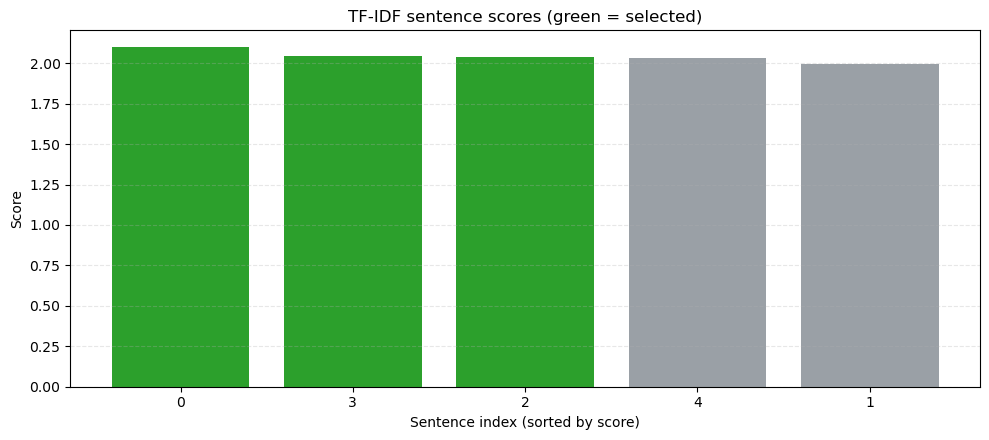

In [60]:
# Visualization cho SAMPLE_VI
viz_sentences = split_sentences(SAMPLE_VI)
viz_selected, viz_meta = summarize_with_tfidf(viz_sentences, max_sentences=3)

viz_tokenized = [_tokenize(s) for s in viz_sentences]
viz_idf = _build_idf(viz_tokenized)
viz_rows = []
for idx, (sent, toks) in enumerate(zip(viz_sentences, viz_tokenized)):
    viz_rows.append(
        {
            "idx": idx,
            "selected": idx in (viz_meta.get("selected_indices") or []),
            "score": _score_sentence(toks, viz_idf),
            "sentence": sent,
            "sentence_preview": sent[:70] + ("..." if len(sent) > 70 else ""),
            "token_count": len(toks),
        }
    )

# Bảng số liệu (pandas nếu có; không có thì in text)
try:
    import pandas as pd
except ImportError:
    pd = None

if pd is not None:
    viz_df = pd.DataFrame(viz_rows).sort_values(["score", "idx"], ascending=[False, True])
    display(viz_df[["idx", "selected", "score", "token_count", "sentence_preview"]])
else:
    for r in sorted(viz_rows, key=lambda x: (-x["score"], x["idx"])):
        mark = "*" if r["selected"] else " "
        print(f"{mark} idx={r['idx']} score={r['score']:.4f} tokens={r['token_count']} | {r['sentence_preview']}")

# Biểu đồ cột
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("Chưa cài matplotlib -> pip install matplotlib")
else:
    order = sorted(viz_rows, key=lambda x: (-x["score"], x["idx"]))
    labels = [f"{r['idx']}" for r in order]
    colors = ["#2ca02c" if r["selected"] else "#9aa0a6" for r in order]

    plt.figure(figsize=(10, 4.5))
    plt.bar(labels, [r["score"] for r in order], color=colors)
    plt.title("TF-IDF sentence scores (green = selected)")
    plt.xlabel("Sentence index (sorted by score)")
    plt.ylabel("Score")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9. Test với dữ liệu VietNews thật (ưu tiên news dài)

Mục tiêu: kiểm tra TF-IDF trên dữ liệu thật và bài dài để đảm bảo tính ổn định.

- **Ưu tiên local**: đọc `data/raw/vietnews/train.jsonl` (hoặc `validation.jsonl`, `test.jsonl`) nếu có.
- **Fallback**: tải từ Hugging Face `nam194/vietnews` khi local chưa sẵn.
- Chuẩn hóa record về format: `title`, `article`, `reference` để dùng chung cho đánh giá.

In [61]:
from datetime import datetime
import csv
import json


def _pick_first_non_empty(rec: dict, keys: list[str]) -> str | None:
    for k in keys:
        if k in rec and rec[k] is not None:
            val = str(rec[k]).strip()
            if val:
                return val
    return None


def _normalize_records(items: list[dict]) -> list[dict]:
    normalized: list[dict] = []
    for rec in items:
        if not isinstance(rec, dict):
            continue
        article = _pick_first_non_empty(
            rec,
            ["article", "content", "text", "body", "document", "news", "input"],
        )
        if not article:
            continue
        reference = _pick_first_non_empty(
            rec,
            ["summary", "abstract", "highlights", "reference", "target", "label"],
        )
        title = _pick_first_non_empty(rec, ["title", "headline", "name"]) or ""
        normalized.append({"title": title, "article": article, "reference": reference})
    return normalized


def load_records_from_path(path: Path, max_rows: int | None = None) -> list[dict]:
    suffix = path.suffix.lower()
    items: list[dict] = []

    if suffix == ".csv":
        with path.open("r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                items.append(dict(row))
                if max_rows and len(items) >= max_rows:
                    break
    elif suffix == ".jsonl":
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                items.append(json.loads(line))
                if max_rows and len(items) >= max_rows:
                    break
    elif suffix == ".json":
        data = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            items = data.get("data", [data]) if isinstance(data.get("data"), list) else [data]
        elif isinstance(data, list):
            items = data
        if max_rows:
            items = items[:max_rows]
    else:
        raise ValueError(f"Chưa hỗ trợ định dạng: {suffix}")

    return _normalize_records(items)


def _candidate_vietnews_paths() -> list[Path]:
    project_root = BACKEND_ROOT.parent
    return [
        project_root / "data" / "raw" / "vietnews" / "train.jsonl",
        project_root / "data" / "raw" / "vietnews" / "validation.jsonl",
        project_root / "data" / "raw" / "vietnews" / "test.jsonl",
    ]


def load_vietnews_records(max_rows: int = 300, split: str = "train") -> tuple[list[dict], str]:
    preferred = BACKEND_ROOT.parent / "data" / "raw" / "vietnews" / f"{split}.jsonl"
    candidates = [preferred] + [p for p in _candidate_vietnews_paths() if p != preferred]

    for path in candidates:
        if path.exists():
            return load_records_from_path(path, max_rows=max_rows), f"local:{path}"

    try:
        from datasets import load_dataset
    except ImportError:
        return [], "none (không có local file, cũng chưa cài datasets)"

    ds = load_dataset("nam194/vietnews", split=split)
    ds = ds.select(range(min(max_rows, len(ds))))
    items = [
        {
            "title": str(rec.get("title", "")).strip(),
            "article": str(rec.get("article", "")).strip(),
            "reference": str(rec.get("abstract", "")).strip() or None,
        }
        for rec in ds
    ]
    return _normalize_records(items), f"hf:nam194/vietnews[{split}]"


MAX_ROWS = 300
HF_SPLIT = "train"
vietnews_records, vietnews_source = load_vietnews_records(max_rows=MAX_ROWS, split=HF_SPLIT)

print(f"Loaded {len(vietnews_records)} records")
print("Source:", vietnews_source)

Loaded 300 records
Source: local:C:\Users\OS\OneDrive\Desktop\Text_Summarization\data\raw\vietnews\train.jsonl


In [62]:
# Chạy evaluation TF-IDF trên VietNews (ưu tiên bài dài)

# Cell này tự nạp dữ liệu nếu bạn chưa chạy cell trước.
if "vietnews_records" not in globals() or not vietnews_records:
    vietnews_records, vietnews_source = load_vietnews_records(max_rows=300, split="train")
    print(f"Auto-loaded {len(vietnews_records)} records from {vietnews_source}")

MIN_CHARS = 1200  # ngưỡng bài dài
RATIOS = (0.2, 0.3, 0.4)
MAX_LONG_DOCS = 120  # để notebook chạy nhanh hơn nếu dataset lớn

try:
    from rouge_score import rouge_scorer
except ImportError:
    rouge_scorer = None

scorer = (
    rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    if rouge_scorer is not None
    else None
)

records_for_eval = [r for r in vietnews_records if len(r.get("article", "")) >= MIN_CHARS]
records_for_eval = records_for_eval[:MAX_LONG_DOCS]
print(f"Source: {vietnews_source}")
print(f"Long-news records (>= {MIN_CHARS} chars): {len(records_for_eval)}")

eval_rows: list[dict] = []
for i, rec in enumerate(records_for_eval):
    try:
        proc = process_from_text(rec["article"])
    except Exception as exc:
        eval_rows.append({"doc_id": i, "error": str(exc), "article_chars": len(rec.get("article", ""))})
        continue

    n_sent = len(proc.sentences)
    if n_sent == 0:
        continue

    for ratio in RATIOS:
        k = max(1, math.ceil(ratio * n_sent))
        selected, meta_local = summarize_with_tfidf(proc.sentences, max_sentences=k)
        hyp = " ".join(selected).strip()

        row = {
            "doc_id": i,
            "title": rec.get("title", "")[:120],
            "article_chars": len(rec["article"]),
            "sentence_count": n_sent,
            "ratio": ratio,
            "k": k,
            "selected_indices": json.dumps(meta_local.get("selected_indices", []), ensure_ascii=False),
            "summary_chars": len(hyp),
            "summary_text": hyp,
            "has_reference": bool(rec.get("reference")),
            "source": vietnews_source,
        }

        if scorer is not None and rec.get("reference"):
            rs = scorer.score(rec["reference"], hyp)
            row.update(
                {
                    "rouge1_f": rs["rouge1"].fmeasure,
                    "rouge2_f": rs["rouge2"].fmeasure,
                    "rougeL_f": rs["rougeL"].fmeasure,
                }
            )
        eval_rows.append(row)

print(f"Generated rows: {len(eval_rows)}")

if eval_rows:
    try:
        import pandas as pd
    except ImportError:
        pd = None

    if pd is not None:
        eval_df = pd.DataFrame(eval_rows)
        show_cols = ["doc_id", "article_chars", "sentence_count", "ratio", "k", "summary_chars"]
        if "rouge1_f" in eval_df.columns:
            show_cols += ["rouge1_f", "rouge2_f", "rougeL_f"]
        display(eval_df[show_cols].head(10))

        agg = eval_df.groupby("ratio", as_index=False).agg(
            avg_article_chars=("article_chars", "mean"),
            avg_sentence_count=("sentence_count", "mean"),
            avg_summary_chars=("summary_chars", "mean"),
        )
        if "rougeL_f" in eval_df.columns:
            agg = agg.merge(
                eval_df.groupby("ratio", as_index=False)[["rouge1_f", "rouge2_f", "rougeL_f"]].mean(),
                on="ratio",
                how="left",
            )
        display(agg)
    else:
        for r in eval_rows[:5]:
            print({k: r.get(k) for k in ["doc_id", "article_chars", "sentence_count", "ratio", "k", "summary_chars"]})
else:
    print("Chưa có dòng evaluation. Kiểm tra dữ liệu hoặc giảm MIN_CHARS.")

Source: local:C:\Users\OS\OneDrive\Desktop\Text_Summarization\data\raw\vietnews\train.jsonl
Long-news records (>= 1200 chars): 120
Generated rows: 360


,doc_id,article_chars,sentence_count,ratio,k,summary_chars,rouge1_f,rouge2_f,rougeL_f
0,0,1576,16,0.2,4,129,0.540000,0.122449,0.340000
1,0,1576,16,0.3,5,219,0.625954,0.186047,0.305344
2,0,1576,16,0.4,7,679,0.412811,0.207885,0.227758
3,1,1224,9,0.2,2,99,0.483871,0.066667,0.193548
4,1,1224,9,0.3,3,148,0.538462,0.078947,0.256410
5,1,1224,9,0.4,4,423,0.278788,0.073620,0.181818
6,2,1692,17,0.2,4,578,0.346320,0.244541,0.329004
7,2,1692,17,0.3,6,709,0.293040,0.214022,0.278388
8,2,1692,17,0.4,7,889,0.243902,0.177914,0.231707
9,3,1416,12,0.2,3,165,0.594059,0.080808,0.297030


,ratio,avg_article_chars,avg_sentence_count,avg_summary_chars,rouge1_f,rouge2_f,rougeL_f
0,0.2,2352.95,18.983333,547.333333,0.424081,0.177168,0.259589
1,0.3,2352.95,18.983333,861.283333,0.335456,0.174899,0.225573
2,0.4,2352.95,18.983333,1123.091667,0.277830,0.163670,0.198881


In [63]:
## 10. Lưu kết quả evaluation để vẽ bảng / biểu đồ sau này

results_dir = Path("./results")
results_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

if not eval_rows:
    print("Không có eval_rows để lưu.")
else:
    csv_path = results_dir / f"tfidf_vietnews_eval_{ts}.csv"

    fieldnames = sorted({k for row in eval_rows for k in row.keys()})
    with csv_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in eval_rows:
            writer.writerow(row)

    report = {
        "created_at": ts,
        "source": vietnews_source if "vietnews_source" in globals() else "unknown",
        "min_chars": MIN_CHARS if "MIN_CHARS" in globals() else None,
        "ratios": list(RATIOS) if "RATIOS" in globals() else None,
        "record_count_total": len(vietnews_records) if "vietnews_records" in globals() else None,
        "record_count_long": len(records_for_eval) if "records_for_eval" in globals() else None,
        "row_count": len(eval_rows),
        "csv_file": str(csv_path),
    }

    json_path = results_dir / f"tfidf_vietnews_eval_{ts}.json"
    json_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"Saved CSV : {csv_path.resolve()}")
    print(f"Saved JSON: {json_path.resolve()}")

Saved CSV : C:\Users\OS\OneDrive\Desktop\Text_Summarization\notebooks\results\tfidf_vietnews_eval_20260415_020332.csv
Saved JSON: C:\Users\OS\OneDrive\Desktop\Text_Summarization\notebooks\results\tfidf_vietnews_eval_20260415_020332.json


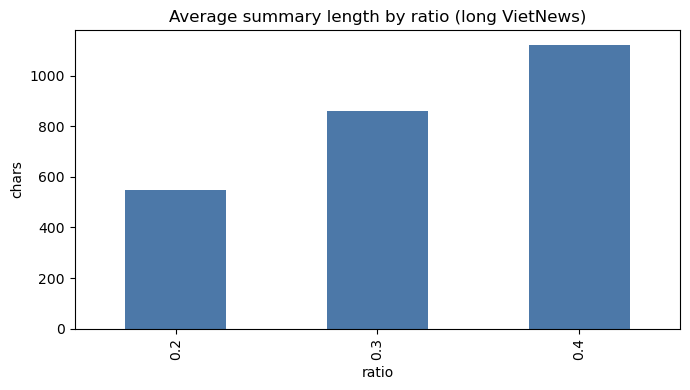

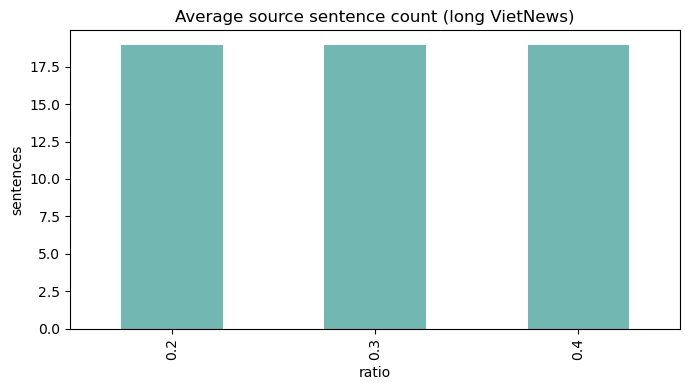

<Figure size 700x400 with 0 Axes>

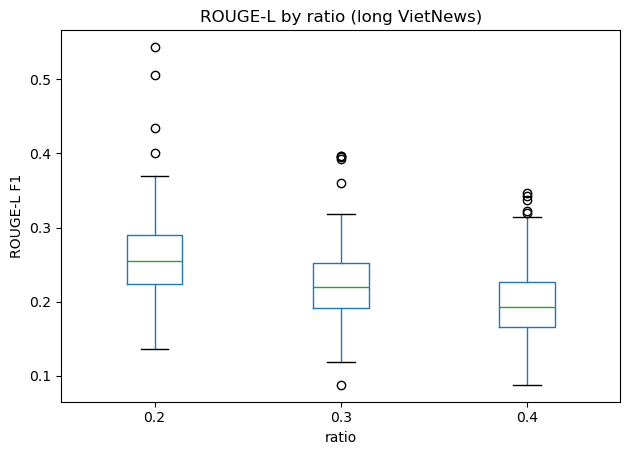

In [64]:
# (Tuỳ chọn) Visualization nhanh cho tập evaluation VietNews dài
if eval_rows:
    try:
        import pandas as pd
        import matplotlib.pyplot as plt
    except ImportError:
        print("Cài thêm pandas/matplotlib để vẽ: pip install pandas matplotlib")
    else:
        eval_df = pd.DataFrame(eval_rows)
        if "ratio" not in eval_df.columns:
            print("Không có cột ratio để vẽ (có thể eval_rows đang chứa lỗi parse).")
        else:
            plt.figure(figsize=(7, 4))
            eval_df.groupby("ratio")["summary_chars"].mean().plot(kind="bar", color="#4c78a8")
            plt.title("Average summary length by ratio (long VietNews)")
            plt.ylabel("chars")
            plt.xlabel("ratio")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(7, 4))
            eval_df.groupby("ratio")["sentence_count"].mean().plot(kind="bar", color="#72b7b2")
            plt.title("Average source sentence count (long VietNews)")
            plt.ylabel("sentences")
            plt.xlabel("ratio")
            plt.tight_layout()
            plt.show()

            if "rougeL_f" in eval_df.columns:
                plt.figure(figsize=(7, 4))
                eval_df.boxplot(column="rougeL_f", by="ratio", grid=False)
                plt.title("ROUGE-L by ratio (long VietNews)")
                plt.suptitle("")
                plt.xlabel("ratio")
                plt.ylabel("ROUGE-L F1")
                plt.tight_layout()
                plt.show()
else:
    print("Chưa có eval_rows để vẽ.")

## 11. Phase 1 chuẩn hoá theo đề bài: sweep `top_k` cố định (2, 3, 4, 5)

Vì đây là **baseline extractive đầu tiên**, ta cố định `top_k` để so sánh công bằng giữa các cấu hình. Kết quả mean ROUGE theo `top_k` sẽ dùng để:

- chọn hyperparameter baseline cho TF-IDF,
- công bố benchmark chính thức trong báo cáo Phase 1,
- làm mốc so sánh cho TextRank / mô hình abstractive ở Phase sau.

In [ ]:
# Sweep top_k cố định theo đề bài: 2, 3, 4, 5
TOP_KS = [2, 3, 4, 5]
PHASE1_MAX_DOCS = 120  # giữ thời gian chạy hợp lý

if "vietnews_records" not in globals() or not vietnews_records:
    vietnews_records, vietnews_source = load_vietnews_records(max_rows=300, split="train")
    print(f"Auto-loaded {len(vietnews_records)} records from {vietnews_source}")

if "MIN_CHARS" not in globals():
    MIN_CHARS = 1200

try:
    from rouge_score import rouge_scorer
except ImportError:
    rouge_scorer = None

phase1_scorer = (
    rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    if rouge_scorer is not None
    else None
)

phase1_records = [r for r in vietnews_records if len(r.get("article", "")) >= MIN_CHARS]
phase1_records = phase1_records[:PHASE1_MAX_DOCS]
print(f"Phase1 source: {vietnews_source}")
print(f"Long-news records used: {len(phase1_records)} (MIN_CHARS={MIN_CHARS})")

topk_eval_rows: list[dict] = []
for i, rec in enumerate(phase1_records):
    try:
        proc = process_from_text(rec["article"])
    except Exception as exc:
        topk_eval_rows.append({"doc_id": i, "error": str(exc), "article_chars": len(rec.get("article", ""))})
        continue

    if not proc.sentences:
        continue

    for top_k in TOP_KS:
        selected, meta_local = summarize_with_tfidf(proc.sentences, max_sentences=top_k)
        hyp = " ".join(selected).strip()
        row = {
            "doc_id": i,
            "title": rec.get("title", "")[:120],
            "article_chars": len(rec["article"]),
            "sentence_count": len(proc.sentences),
            "top_k": top_k,
            "summary_chars": len(hyp),
            "selected_indices": json.dumps(meta_local.get("selected_indices", []), ensure_ascii=False),
            "summary_text": hyp,
            "has_reference": bool(rec.get("reference")),
            "source": vietnews_source,
        }

        if phase1_scorer is not None and rec.get("reference"):
            rs = phase1_scorer.score(rec["reference"], hyp)
            row.update(
                {
                    "rouge1_f": rs["rouge1"].fmeasure,
                    "rouge2_f": rs["rouge2"].fmeasure,
                    "rougeL_f": rs["rougeL"].fmeasure,
                }
            )
        topk_eval_rows.append(row)

print(f"Generated rows for top_k sweep: {len(topk_eval_rows)}")

try:
    import pandas as pd
except ImportError:
    pd = None

if pd is None:
    print("Cài pandas để xem bảng tổng hợp: pip install pandas")
else:
    topk_eval_df = pd.DataFrame(topk_eval_rows)
    show_cols = ["doc_id", "article_chars", "sentence_count", "top_k", "summary_chars"]
    if "rouge1_f" in topk_eval_df.columns:
        show_cols += ["rouge1_f", "rouge2_f", "rougeL_f"]
    display(topk_eval_df[show_cols].head(12))

In [ ]:
# Tổng hợp benchmark chính thức Phase 1 (mean ROUGE theo top_k)
if "topk_eval_rows" not in globals() or not topk_eval_rows:
    print("Chưa có topk_eval_rows. Hãy chạy cell sweep top_k trước.")
else:
    try:
        import pandas as pd
    except ImportError:
        pd = None

    if pd is None:
        print("Cài pandas để tổng hợp benchmark: pip install pandas")
    else:
        topk_eval_df = pd.DataFrame(topk_eval_rows)
        required_cols = {"top_k", "rouge1_f", "rouge2_f", "rougeL_f"}
        if not required_cols.issubset(set(topk_eval_df.columns)):
            print("Thiếu cột ROUGE. Kiểm tra rouge-score/reference trước khi tổng hợp.")
        else:
            summary_df = (
                topk_eval_df.groupby("top_k", as_index=False)
                .agg(
                    rouge1_f_mean=("rouge1_f", "mean"),
                    rouge2_f_mean=("rouge2_f", "mean"),
                    rougeL_f_mean=("rougeL_f", "mean"),
                    doc_count=("doc_id", "nunique"),
                    row_count=("doc_id", "count"),
                    avg_summary_chars=("summary_chars", "mean"),
                )
                .sort_values("top_k")
            )
            display(summary_df)

            # Chọn top_k baseline theo ROUGE-L mean (có thể đổi tiêu chí nếu cần)
            best_row = summary_df.sort_values("rougeL_f_mean", ascending=False).iloc[0]
            best_topk = int(best_row["top_k"])

            print("\nTF-IDF baseline result (Phase 1):")
            print(f"top_k: {best_topk}")
            print(f"ROUGE-1: {best_row['rouge1_f_mean']:.4f}")
            print(f"ROUGE-2: {best_row['rouge2_f_mean']:.4f}")
            print(f"ROUGE-L: {best_row['rougeL_f_mean']:.4f}")

            # Lưu artefact benchmark Phase 1
            ts = datetime.now().strftime("%Y%m%d_%H%M%S")
            results_dir = Path("./results")
            results_dir.mkdir(parents=True, exist_ok=True)

            detail_csv = results_dir / f"tfidf_phase1_topk_detail_{ts}.csv"
            summary_csv = results_dir / f"tfidf_phase1_topk_summary_{ts}.csv"
            topk_eval_df.to_csv(detail_csv, index=False, encoding="utf-8")
            summary_df.to_csv(summary_csv, index=False, encoding="utf-8")

            report = {
                "created_at": ts,
                "source": vietnews_source if "vietnews_source" in globals() else "unknown",
                "min_chars": MIN_CHARS if "MIN_CHARS" in globals() else None,
                "top_ks": TOP_KS if "TOP_KS" in globals() else [2, 3, 4, 5],
                "doc_count": int(best_row["doc_count"]),
                "best_top_k": best_topk,
                "rouge1_mean": float(best_row["rouge1_f_mean"]),
                "rouge2_mean": float(best_row["rouge2_f_mean"]),
                "rougeL_mean": float(best_row["rougeL_f_mean"]),
                "detail_csv": str(detail_csv),
                "summary_csv": str(summary_csv),
            }
            report_json = results_dir / f"tfidf_phase1_topk_report_{ts}.json"
            report_json.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

            print("\nSaved phase1 files:")
            print(f"- detail:  {detail_csv.resolve()}")
            print(f"- summary: {summary_csv.resolve()}")
            print(f"- report:  {report_json.resolve()}")